In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from category_encoders import TargetEncoder
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.model_selection import cross_val_score, train_test_split, KFold
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.inspection import permutation_importance
from eli5.sklearn import PermutationImportance
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
import joblib

In [2]:
# Load the dataset
file_path = "avito_data_EDA.csv"
df = pd.read_csv(file_path)

# Make a copy to clean
df_Processing = df.copy()

In [3]:
df_Processing.shape

(45957, 14)

In [4]:
# Check for missing values
print(df_Processing.isna().sum())

Secteur                               0
Ville                                 0
Boite de vitesses                     0
Type de carburant                     0
Marque                                0
Modele                                0
Nombre de portes                      0
Origine                               0
Premiere main                         0
Puissance fiscale                     0
Etat                                  0
log_price (en milliers MAD)           0
Kilometrage lisse (en milliers km)    0
Age (annees)                          0
dtype: int64


In [5]:
# list of categorical columns to target encode
target_cols = ['Secteur', 'Ville', 'Marque', 'Modele']
target = 'log_price (en milliers MAD)'

# initialize the encoder
target_encoder = TargetEncoder(cols=target_cols)

df_Processing.head()

,Secteur,Ville,Boite de vitesses,Type de carburant,Marque,Modele,Nombre de portes,Origine,Premiere main,Puissance fiscale,Etat,log_price (en milliers MAD),Kilometrage lisse (en milliers km),Age (annees)
0,route ain chkaf,fès,Automatique,Diesel,volkswagen,golf 7,5,WW au Maroc,False,7,Très bon,5.117994,5.694376,8
1,hay karima,salé,Manuelle,Essence,renault,megane,5,WW au Maroc,True,9,Très bon,3.828641,329.689244,17
2,anfa,casablanca,Automatique,Diesel,porsche,macan,5,WW au Maroc,False,12,Excellent,5.752573,221.320681,10
3,bir rami,kénitra,Manuelle,Diesel,renault,clio,5,WW au Maroc,True,6,Bon,4.700480,106.898035,6
4,centre ville,tanger,Automatique,Diesel,mercedes-benz,classe c,5,Importée neuve,False,7,Très bon,5.541264,155.515300,10


In [6]:
# -------- One-Hot Encoding --------
# Columns to one-hot encode
onehot_cols = [
    'Boite de vitesses',
    'Type de carburant',
    'Nombre de portes',
    'Origine',
    'Etat'
]

# Apply one-hot encoding in a simple for loop
for col in onehot_cols:
    dummies = pd.get_dummies(df_Processing[col], prefix=col)
    df_Processing = pd.concat([df_Processing.drop(columns=[col]), dummies], axis=1)

df_Processing.head()

,Secteur,Ville,Marque,Modele,Premiere main,Puissance fiscale,log_price (en milliers MAD),Kilometrage lisse (en milliers km),Age (annees),Boite de vitesses_Automatique,...,Origine_Importée neuve,Origine_Pas encore dédouanée,Origine_WW au Maroc,Etat_Bon,Etat_Correct,Etat_Endommagé,Etat_Excellent,Etat_Neuf,Etat_Pour Pièces,Etat_Très bon
0,route ain chkaf,fès,volkswagen,golf 7,False,7,5.117994,5.694376,8,True,...,False,False,True,False,False,False,False,False,False,True
1,hay karima,salé,renault,megane,True,9,3.828641,329.689244,17,False,...,False,False,True,False,False,False,False,False,False,True
2,anfa,casablanca,porsche,macan,False,12,5.752573,221.320681,10,True,...,False,False,True,False,False,False,True,False,False,False
3,bir rami,kénitra,renault,clio,True,6,4.700480,106.898035,6,False,...,False,False,True,True,False,False,False,False,False,False
4,centre ville,tanger,mercedes-benz,classe c,False,7,5.541264,155.515300,10,True,...,True,False,False,False,False,False,False,False,False,True


In [7]:
# List of columns to scale
columns_to_scale = ['Puissance fiscale', 'Kilometrage lisse (en milliers km)', 'Age (annees)']

# Create a StandardScaler object
scaler = StandardScaler()

# Apply scaling
df_Processing[columns_to_scale] = scaler.fit_transform(df_Processing[columns_to_scale])

# Check the scaled data
df_Processing.head(5)

,Secteur,Ville,Marque,Modele,Premiere main,Puissance fiscale,log_price (en milliers MAD),Kilometrage lisse (en milliers km),Age (annees),Boite de vitesses_Automatique,...,Origine_Importée neuve,Origine_Pas encore dédouanée,Origine_WW au Maroc,Etat_Bon,Etat_Correct,Etat_Endommagé,Etat_Excellent,Etat_Neuf,Etat_Pour Pièces,Etat_Très bon
0,route ain chkaf,fès,volkswagen,golf 7,False,-0.124714,5.117994,-1.447711,-0.659028,True,...,False,False,True,False,False,False,False,False,False,True
1,hay karima,salé,renault,megane,True,0.901881,3.828641,1.951975,0.564956,False,...,False,False,True,False,False,False,False,False,False,True
2,anfa,casablanca,porsche,macan,False,2.441772,5.752573,0.814861,-0.387031,True,...,False,False,True,False,False,False,True,False,False,False
3,bir rami,kénitra,renault,clio,True,-0.638011,4.700480,-0.385779,-0.931024,False,...,False,False,True,True,False,False,False,False,False,False
4,centre ville,tanger,mercedes-benz,classe c,False,-0.124714,5.541264,0.124364,-0.387031,True,...,True,False,False,False,False,False,False,False,False,True


In [8]:
df_Processing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45957 entries, 0 to 45956
Data columns (total 29 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Secteur                             45957 non-null  object 
 1   Ville                               45957 non-null  object 
 2   Marque                              45957 non-null  object 
 3   Modele                              45957 non-null  object 
 4   Premiere main                       45957 non-null  bool   
 5   Puissance fiscale                   45957 non-null  float64
 6   log_price (en milliers MAD)         45957 non-null  float64
 7   Kilometrage lisse (en milliers km)  45957 non-null  float64
 8   Age (annees)                        45957 non-null  float64
 9   Boite de vitesses_Automatique       45957 non-null  bool   
 10  Boite de vitesses_Manuelle          45957 non-null  bool   
 11  Type de carburant_Diesel            45957

In [9]:
# Find all boolean columns and convert them to int64
bool_columns = df_Processing.select_dtypes(include=[bool]).columns
for col in bool_columns:
    df_Processing[col] = df_Processing[col].astype(int)

# Check the updated DataFrame
df_Processing.head(5)

,Secteur,Ville,Marque,Modele,Premiere main,Puissance fiscale,log_price (en milliers MAD),Kilometrage lisse (en milliers km),Age (annees),Boite de vitesses_Automatique,...,Origine_Importée neuve,Origine_Pas encore dédouanée,Origine_WW au Maroc,Etat_Bon,Etat_Correct,Etat_Endommagé,Etat_Excellent,Etat_Neuf,Etat_Pour Pièces,Etat_Très bon
0,route ain chkaf,fès,volkswagen,golf 7,0,-0.124714,5.117994,-1.447711,-0.659028,1,...,0,0,1,0,0,0,0,0,0,1
1,hay karima,salé,renault,megane,1,0.901881,3.828641,1.951975,0.564956,0,...,0,0,1,0,0,0,0,0,0,1
2,anfa,casablanca,porsche,macan,0,2.441772,5.752573,0.814861,-0.387031,1,...,0,0,1,0,0,0,1,0,0,0
3,bir rami,kénitra,renault,clio,1,-0.638011,4.700480,-0.385779,-0.931024,0,...,0,0,1,1,0,0,0,0,0,0
4,centre ville,tanger,mercedes-benz,classe c,0,-0.124714,5.541264,0.124364,-0.387031,1,...,1,0,0,0,0,0,0,0,0,1


In [10]:
# --- Subset with full features ---
X = df_Processing.drop(columns=['log_price (en milliers MAD)'])
y = df_Processing['log_price (en milliers MAD)']

# --- Split into train and test sets ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- target encode the categorical columns in the training set ---
X_train[target_cols] = target_encoder.fit_transform(X_train[target_cols], y_train)
X_test[target_cols] = target_encoder.transform(X_test[target_cols])

# --- Initialize and fit the tuned Random Forest model ---
model_selected = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42
)
model_selected.fit(X_train, y_train)

# --- Predictions ---
y_pred_train = model_selected.predict(X_train)
y_pred_test = model_selected.predict(X_test)

# --- Convert predictions and targets back to actual prices ---
y_train_actual = np.exp(y_train)
y_test_actual = np.exp(y_test)
y_pred_train_actual = np.exp(y_pred_train)
y_pred_test_actual = np.exp(y_pred_test)

# --- Metrics on actual prices ---
r2_train_actual = r2_score(y_train_actual, y_pred_train_actual)
mae_train_actual = mean_absolute_error(y_train_actual, y_pred_train_actual)
rmse_train_actual = np.sqrt(mean_squared_error(y_train_actual, y_pred_train_actual))

r2_test_actual = r2_score(y_test_actual, y_pred_test_actual)
mae_test_actual = mean_absolute_error(y_test_actual, y_pred_test_actual)
rmse_test_actual = np.sqrt(mean_squared_error(y_test_actual, y_pred_test_actual))

# --- Cross-validation (use original y, then exp for metrics) ---
# Predict and evaluate manually for actual values
cv_r2_actual_list = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in kf.split(X):
    # Split into training and validation folds
    X_tr, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # --- Apply target encoding only on training fold ---
    encoder = TargetEncoder()
    X_tr[target_cols] = encoder.fit_transform(X_tr[target_cols], y_tr)
    X_val[target_cols] = encoder.transform(X_val[target_cols])

    # --- Train model ---
    model_cv = RandomForestRegressor(
        n_estimators=300,
        max_depth=20,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42
    )
    model_cv.fit(X_tr, y_tr)

    # --- Predict and convert back to actual prices ---
    y_val_pred = model_cv.predict(X_val)
    y_val_actual = np.exp(y_val)
    y_val_pred_actual = np.exp(y_val_pred)

    # --- R² score for this fold ---
    r2_cv = r2_score(y_val_actual, y_val_pred_actual)
    cv_r2_actual_list.append(r2_cv)

# --- Final cross-validation mean R² score ---
cv_r2_mean_actual = np.mean(cv_r2_actual_list)

# --- Display results ---
print("Train R² (actual price):", round(r2_train_actual, 5))
print("Train MAE (actual price):", round(mae_train_actual, 5))
print("Train RMSE (actual price):", round(rmse_train_actual, 5))
print("Test R² (actual price):", round(r2_test_actual, 5))
print("Test MAE (actual price):", round(mae_test_actual, 5))
print("Test RMSE (actual price):", round(rmse_test_actual, 5))
print("Cross-validated R² mean (actual price):", round(cv_r2_mean_actual, 5))

Train R² (actual price): 0.93377
Train MAE (actual price): 10.90111
Train RMSE (actual price): 17.66736
Test R² (actual price): 0.87165
Test MAE (actual price): 15.18858
Test RMSE (actual price): 24.31724
Cross-validated R² mean (actual price): 0.8718


# permutation_importance

In [11]:
# --- Split the data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Initialize and fit TargetEncoder on training set ---
X_train[target_cols] = target_encoder.fit_transform(X_train[target_cols], y_train)
X_val[target_cols] = target_encoder.transform(X_val[target_cols])

# --- Fit the RandomForestRegressor model ---
model = RandomForestRegressor(n_estimators=300, random_state=42)
model.fit(X_train, y_train)

# --- Compute permutation importance using eli5 ---
perm = PermutationImportance(model, scoring='r2', n_iter=5, random_state=42)
perm.fit(X_val, y_val)

# --- Create DataFrame for better visualization ---
perm_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# --- Compute cumulative importance ---
perm_importance_df['Cumulative'] = perm_importance_df['Importance'].cumsum()

# --- Select top features that cover 99.5% importance ---
total_importance = perm_importance_df['Importance'].sum()
threshold = total_importance * 0.999
selected_perm_features = perm_importance_df[
    perm_importance_df['Cumulative'] <= threshold
]['Feature'].tolist()

# --- Include the feature that crosses the threshold ---
if len(selected_perm_features) < len(perm_importance_df):
    selected_perm_features.append(
        perm_importance_df.loc[len(selected_perm_features), 'Feature']
    )

# --- Output ---
print(f"Selected features covering 99.5% of total importance: {len(selected_perm_features)}")
print(selected_perm_features)

Selected features covering 99.5% of total importance: 16
['Age (annees)', 'Modele', 'Marque', 'Boite de vitesses_Manuelle', 'Puissance fiscale', 'Type de carburant_Essence', 'Kilometrage lisse (en milliers km)', 'Type de carburant_Diesel', 'Secteur', 'Origine_WW au Maroc', 'Ville', 'Origine_Dédouanée', 'Premiere main', 'Etat_Bon', 'Boite de vitesses_Automatique', 'Etat_Excellent']


In [12]:
# --- Initialize and fit the tuned Random Forest model ---
model_selected = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42
)
model_selected.fit(X_train, y_train)

# --- Predictions ---
y_pred_train = model_selected.predict(X_train)
y_pred_test = model_selected.predict(X_test)

# --- Convert log predictions and true values to actual prices ---
y_train_actual = np.exp(y_train)
y_test_actual = np.exp(y_test)
y_pred_train_actual = np.exp(y_pred_train)
y_pred_test_actual = np.exp(y_pred_test)

# --- Metrics on actual prices ---
r2_train_actual = r2_score(y_train_actual, y_pred_train_actual)
mae_train_actual = mean_absolute_error(y_train_actual, y_pred_train_actual)
rmse_train_actual = np.sqrt(mean_squared_error(y_train_actual, y_pred_train_actual))

r2_test_actual = r2_score(y_test_actual, y_pred_test_actual)
mae_test_actual = mean_absolute_error(y_test_actual, y_pred_test_actual)
rmse_test_actual = np.sqrt(mean_squared_error(y_test_actual, y_pred_test_actual))

# --- Cross-validation R² using actual prices ---
cv_r2_actual_list = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in kf.split(X):
    # Split into training and validation folds
    X_tr, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # --- Apply target encoding only on training fold ---
    encoder = TargetEncoder()
    X_tr[target_cols] = encoder.fit_transform(X_tr[target_cols], y_tr)
    X_val[target_cols] = encoder.transform(X_val[target_cols])

    # --- Train model ---
    model_cv = RandomForestRegressor(
        n_estimators=300,
        max_depth=20,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42
    )
    model_cv.fit(X_tr, y_tr)

    # --- Predict and convert back to actual prices ---
    y_val_pred = model_cv.predict(X_val)
    y_val_actual = np.exp(y_val)
    y_val_pred_actual = np.exp(y_val_pred)

    # --- R² score for this fold ---
    r2_cv = r2_score(y_val_actual, y_val_pred_actual)
    cv_r2_actual_list.append(r2_cv)

# --- Final cross-validation mean R² score ---
cv_r2_mean_actual = np.mean(cv_r2_actual_list)

# --- Display results ---
print("Train R² (actual price):", round(r2_train_actual, 5))
print("Train MAE (actual price):", round(mae_train_actual, 5))
print("Train RMSE (actual price):", round(rmse_train_actual, 5))
print("Test R² (actual price):", round(r2_test_actual, 5))
print("Test MAE (actual price):", round(mae_test_actual, 5))
print("Test RMSE (actual price):", round(rmse_test_actual, 5))
print("Cross-validated R² mean (actual price):", round(cv_r2_mean_actual, 5))

Train R² (actual price): 0.93377
Train MAE (actual price): 10.90111
Train RMSE (actual price): 17.66736
Test R² (actual price): 0.87165
Test MAE (actual price): 15.18858
Test RMSE (actual price): 24.31724
Cross-validated R² mean (actual price): 0.8718


In [13]:
# --- Initialize and fit XGBoost model ---
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)

# --- Predict on train and test sets ---
y_pred_train = xgb.predict(X_train)
y_pred_test = xgb.predict(X_test)

# --- Convert log values to actual prices ---
y_train_actual = np.exp(y_train)
y_test_actual = np.exp(y_test)
y_pred_train_actual = np.exp(y_pred_train)
y_pred_test_actual = np.exp(y_pred_test)

# --- Train metrics (actual price) ---
r2_train = r2_score(y_train_actual, y_pred_train_actual)
mae_train = mean_absolute_error(y_train_actual, y_pred_train_actual)
rmse_train = np.sqrt(mean_squared_error(y_train_actual, y_pred_train_actual))

# --- Test metrics (actual price) ---
r2_test = r2_score(y_test_actual, y_pred_test_actual)
mae_test = mean_absolute_error(y_test_actual, y_pred_test_actual)
rmse_test = np.sqrt(mean_squared_error(y_test_actual, y_pred_test_actual))

# --- Cross-validation on training set (actual price) ---
cv_r2_actual_list = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in kf.split(X):
    # Split into training and validation folds
    X_tr, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # --- Apply target encoding only on training fold ---
    encoder = TargetEncoder()
    X_tr[target_cols] = encoder.fit_transform(X_tr[target_cols], y_tr)
    X_val[target_cols] = encoder.transform(X_val[target_cols])

    # --- Train model ---
    xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
    xgb.fit(X_tr, y_tr)

    # --- Predict and convert back to actual prices ---
    y_val_pred = xgb.predict(X_val)
    y_val_actual = np.exp(y_val)
    y_val_pred_actual = np.exp(y_val_pred)

    # --- R² score for this fold ---
    r2_cv = r2_score(y_val_actual, y_val_pred_actual)
    cv_r2_actual_list.append(r2_cv)

# --- Final cross-validation mean R² score ---
cv_r2_mean_actual = np.mean(cv_r2_actual_list)

# --- Display results ---
print("XGBoost Train R² (actual price):", round(r2_train, 5))
print("XGBoost Train MAE (actual price):", round(mae_train, 5))
print("XGBoost Train RMSE (actual price):", round(rmse_train, 5))
print("XGBoost Test R² (actual price):", round(r2_test, 5))
print("XGBoost Test MAE (actual price):", round(mae_test, 5))
print("XGBoost Test RMSE (actual price):", round(rmse_test, 5))
print("XGBoost Cross-validated R² mean (actual price):", round(cv_r2_mean_actual, 5))

XGBoost Train R² (actual price): 0.90877
XGBoost Train MAE (actual price): 13.19921
XGBoost Train RMSE (actual price): 20.73616
XGBoost Test R² (actual price): 0.89012
XGBoost Test MAE (actual price): 14.0113
XGBoost Test RMSE (actual price): 22.49986
XGBoost Cross-validated R² mean (actual price): 0.88989


In [14]:
# --- Initialize and fit CatBoost model ---
cat = CatBoostRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    verbose=0  # Suppress training output
)
cat.fit(X_train, y_train)

# --- Predict on train and test sets ---
y_pred_train = cat.predict(X_train)
y_pred_test = cat.predict(X_test)

# --- Convert log values to actual prices ---
y_train_actual = np.exp(y_train)
y_test_actual = np.exp(y_test)
y_pred_train_actual = np.exp(y_pred_train)
y_pred_test_actual = np.exp(y_pred_test)

# --- Train metrics (actual price) ---
r2_train = r2_score(y_train_actual, y_pred_train_actual)
mae_train = mean_absolute_error(y_train_actual, y_pred_train_actual)
rmse_train = np.sqrt(mean_squared_error(y_train_actual, y_pred_train_actual))

# --- Test metrics (actual price) ---
r2_test = r2_score(y_test_actual, y_pred_test_actual)
mae_test = mean_absolute_error(y_test_actual, y_pred_test_actual)
rmse_test = np.sqrt(mean_squared_error(y_test_actual, y_pred_test_actual))

# --- Cross-validation on training set (actual price) ---
cv_r2_actual_list = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in kf.split(X):
    # Split into training and validation folds
    X_tr, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # --- Apply target encoding only on training fold ---
    encoder = TargetEncoder()
    X_tr[target_cols] = encoder.fit_transform(X_tr[target_cols], y_tr)
    X_val[target_cols] = encoder.transform(X_val[target_cols])

    # --- Train model ---
    cat = CatBoostRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        verbose=0  # Suppress training output
    )
    cat.fit(X_tr, y_tr)

    # --- Predict and convert back to actual prices ---
    y_val_pred = cat.predict(X_val)
    y_val_actual = np.exp(y_val)
    y_val_pred_actual = np.exp(y_val_pred)

    # --- R² score for this fold ---
    r2_cv = r2_score(y_val_actual, y_val_pred_actual)
    cv_r2_actual_list.append(r2_cv)

# --- Final cross-validation mean R² score ---
cv_r2_mean_actual = np.mean(cv_r2_actual_list)

# --- Display results ---
print("CatBoost Train R² (actual price):", round(r2_train, 5))
print("CatBoost Train MAE (actual price):", round(mae_train, 5))
print("CatBoost Train RMSE (actual price):", round(rmse_train, 5))
print("CatBoost Test R² (actual price):", round(r2_test, 5))
print("CatBoost Test MAE (actual price):", round(mae_test, 5))
print("CatBoost Test RMSE (actual price):", round(rmse_test, 5))
print("CatBoost Cross-validated R² mean (actual price):", round(cv_r2_mean_actual, 5))

CatBoost Train R² (actual price): 0.87557
CatBoost Train MAE (actual price): 15.70016
CatBoost Train RMSE (actual price): 24.21724
CatBoost Test R² (actual price): 0.86835
CatBoost Test MAE (actual price): 15.89561
CatBoost Test RMSE (actual price): 24.62838
CatBoost Cross-validated R² mean (actual price): 0.86924


In [15]:
# --- Initialize and fit GBR model ---
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    min_samples_leaf=2,
    random_state=42
)
gbr.fit(X_train, y_train)

# --- Train predictions and metrics ---
y_pred_train = gbr.predict(X_train)
y_pred_train_actual = np.exp(y_pred_train)
y_train_actual = np.exp(y_train)

r2_train = r2_score(y_train_actual, y_pred_train_actual)
mae_train = mean_absolute_error(y_train_actual, y_pred_train_actual)
rmse_train = np.sqrt(mean_squared_error(y_train_actual, y_pred_train_actual))

# --- Test predictions and metrics ---
y_pred_test = gbr.predict(X_test)
y_pred_test_actual = np.exp(y_pred_test)
y_test_actual = np.exp(y_test)

r2_test = r2_score(y_test_actual, y_pred_test_actual)
mae_test = mean_absolute_error(y_test_actual, y_pred_test_actual)
rmse_test = np.sqrt(mean_squared_error(y_test_actual, y_pred_test_actual))

# --- Cross-validation on training set (actual price) ---
cv_r2_actual_list = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in kf.split(X):
    # Split into training and validation folds
    X_tr, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # --- Apply target encoding only on training fold ---
    encoder = TargetEncoder()
    X_tr[target_cols] = encoder.fit_transform(X_tr[target_cols], y_tr)
    X_val[target_cols] = encoder.transform(X_val[target_cols])

    # --- Train model ---
    gbr = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        min_samples_leaf=2,
        random_state=42
    )
    gbr.fit(X_tr, y_tr)

    # --- Predict and convert back to actual prices ---
    y_val_pred = gbr.predict(X_val)
    y_val_actual = np.exp(y_val)
    y_val_pred_actual = np.exp(y_val_pred)

    # --- R² score for this fold ---
    r2_cv = r2_score(y_val_actual, y_val_pred_actual)
    cv_r2_actual_list.append(r2_cv)

# --- Final cross-validation mean R² score ---
cv_r2_mean_actual = np.mean(cv_r2_actual_list)

# --- Display results ---
print("GBR Train R² (actual price):", round(r2_train, 5))
print("GBR Train MAE (actual price):", round(mae_train, 5))
print("GBR Train RMSE (actual price):", round(rmse_train, 5))
print("GBR Test R² (actual price):", round(r2_test, 5))
print("GBR Test MAE (actual price):", round(mae_test, 5))
print("GBR Test RMSE (actual price):", round(rmse_test, 5))
print("GBR Cross-validated R² mean (actual price):", round(cv_r2_mean_actual, 5))

GBR Train R² (actual price): 0.90461
GBR Train MAE (actual price): 13.50457
GBR Train RMSE (actual price): 21.20322
GBR Test R² (actual price): 0.88886
GBR Test MAE (actual price): 14.12836
GBR Test RMSE (actual price): 22.62859
GBR Cross-validated R² mean (actual price): 0.88906


In [16]:
# --- Initialize and fit LGBM model ---
lgbm = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=10,
    random_state=42
)
lgbm.fit(X_train, y_train)

# --- Train predictions and metrics ---
y_pred_train = lgbm.predict(X_train)
y_pred_train_actual = np.exp(y_pred_train)
y_train_actual = np.exp(y_train)

r2_train = r2_score(y_train_actual, y_pred_train_actual)
mae_train = mean_absolute_error(y_train_actual, y_pred_train_actual)
rmse_train = np.sqrt(mean_squared_error(y_train_actual, y_pred_train_actual))

# --- Test predictions and metrics ---
y_pred_test = lgbm.predict(X_test)
y_pred_test_actual = np.exp(y_pred_test)
y_test_actual = np.exp(y_test)

r2_test = r2_score(y_test_actual, y_pred_test_actual)
mae_test = mean_absolute_error(y_test_actual, y_pred_test_actual)
rmse_test = np.sqrt(mean_squared_error(y_test_actual, y_pred_test_actual))

# --- Cross-validation (on training set with actual price) ---
cv_r2_actual_list = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in kf.split(X):
    # Split into training and validation folds
    X_tr, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # --- Apply target encoding only on training fold ---
    encoder = TargetEncoder()
    X_tr[target_cols] = encoder.fit_transform(X_tr[target_cols], y_tr)
    X_val[target_cols] = encoder.transform(X_val[target_cols])

    # --- Train model ---
    lgbm = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=10,
    random_state=42
    )
    lgbm.fit(X_tr, y_tr)

    # --- Predict and convert back to actual prices ---
    y_val_pred = lgbm.predict(X_val)
    y_val_actual = np.exp(y_val)
    y_val_pred_actual = np.exp(y_val_pred)

    # --- R² score for this fold ---
    r2_cv = r2_score(y_val_actual, y_val_pred_actual)
    cv_r2_actual_list.append(r2_cv)

# --- Final cross-validation mean R² score ---
cv_r2_mean_actual = np.mean(cv_r2_actual_list)

# --- Display results ---
print("LGBM Train R² (actual price):", round(r2_train, 5))
print("LGBM Train MAE (actual price):", round(mae_train, 5))
print("LGBM Train RMSE (actual price):", round(rmse_train, 5))
print("LGBM Test R² (actual price):", round(r2_test, 5))
print("LGBM Test MAE (actual price):", round(mae_test, 5))
print("LGBM Test RMSE (actual price):", round(rmse_test, 5))
print("LGBM Cross-validated R² mean (actual price):", round(cv_r2_mean_actual, 5))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012206 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 981
[LightGBM] [Info] Number of data points in the train set: 36765, number of used features: 27
[LightGBM] [Info] Start training from score 4.599344
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010722 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 981
[LightGBM] [Info] Number of data points in the train set: 36765, number of used features: 27
[LightGBM] [Info] Start training from score 4.599344
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of test

In [17]:
# --- Filter the original train and test sets ---
X_selected = X[selected_perm_features]
X_train_selected = X_train[selected_perm_features]
X_test_selected = X_test[selected_perm_features]

# --- Optionally add the target variable if you want a full dataset for export ---
selected_df = X_selected.copy()
selected_df['log_price (en milliers MAD)'] = y

train_selected_df = X_train_selected.copy()
train_selected_df['log_price (en milliers MAD)'] = y_train

test_selected_df = X_test_selected.copy()
test_selected_df['log_price (en milliers MAD)'] = y_test

# --- Save to CSV ---
selected_df.to_csv("cars.csv",index=False)
train_selected_df.to_csv("train_selected.csv", index=False)
test_selected_df.to_csv("test_selected.csv", index=False)


In [18]:
selected_df.isna().sum()

Age (annees)                          0
Modele                                0
Marque                                0
Boite de vitesses_Manuelle            0
Puissance fiscale                     0
Type de carburant_Essence             0
Kilometrage lisse (en milliers km)    0
Type de carburant_Diesel              0
Secteur                               0
Origine_WW au Maroc                   0
Ville                                 0
Origine_Dédouanée                     0
Premiere main                         0
Etat_Bon                              0
Boite de vitesses_Automatique         0
Etat_Excellent                        0
log_price (en milliers MAD)           0
dtype: int64

# Final

In [19]:
# --- Style ---
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# --- Load train and test data ---
df_train = pd.read_csv("train_selected.csv")  # Assuming your train data is in 'train.csv'
df_test = pd.read_csv("test_selected.csv")    # Assuming your test data is in 'test.csv'

# --- Split features and target for train and test data ---
X_train = df_train.drop(columns='log_price (en milliers MAD)')
y_train_log = df_train['log_price (en milliers MAD)']  # This is in log scale

X_test = df_test.drop(columns='log_price (en milliers MAD)')
y_test_log = df_test['log_price (en milliers MAD)']  # This is in log scale

# --- Model ---
model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=10,
    random_state=42
)
model.fit(X_train, y_train_log)

# --- Predictions ---
y_train_pred_log = model.predict(X_train)
y_test_pred_log = model.predict(X_test)

# --- Inverse transform to actual price scale ---
y_train = np.expm1(y_train_log)
y_test = np.expm1(y_test_log)
y_train_pred = np.expm1(y_train_pred_log)
y_test_pred = np.expm1(y_test_pred_log)

# --- Evaluation ---
def evaluate(y_true, y_pred, dataset=""):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{dataset} R²: {r2:.5f}")
    print(f"{dataset} MAE: {mae:.5f}")
    print(f"{dataset} RMSE: {rmse:.5f}\n")
    return r2, mae, rmse

print("Evaluation Metrics (Original Price Scale):\n")
train_scores = evaluate(y_train, y_train_pred, "Train")
test_scores = evaluate(y_test, y_test_pred, "Test")

# --- Cross-validation ---
cv_scores = cross_val_score(model, X_train, y_train_log, cv=5, scoring='r2')
print(f"Cross-validated R² (log scale, Train Set): {cv_scores.mean():.5f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002023 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 959
[LightGBM] [Info] Number of data points in the train set: 36765, number of used features: 16
[LightGBM] [Info] Start training from score 4.599344
Evaluation Metrics (Original Price Scale):

Train R²: 0.91099
Train MAE: 12.95703
Train RMSE: 20.48227

Test R²: 0.89527
Test MAE: 13.62481
Test RMSE: 21.96606

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004844 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 957
[LightGBM] [Inf

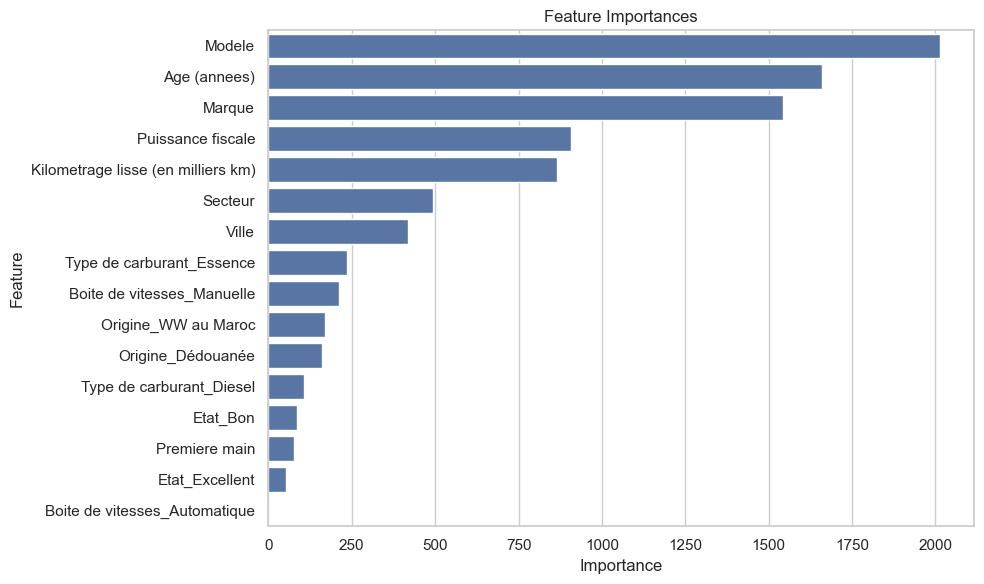

In [20]:
# --- Plot: Feature Importances ---
importances = model.feature_importances_
features = X_train.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure()
sns.barplot(data=importance_df, x='Importance', y='Feature')
plt.title("Feature Importances")
plt.tight_layout()
plt.show()

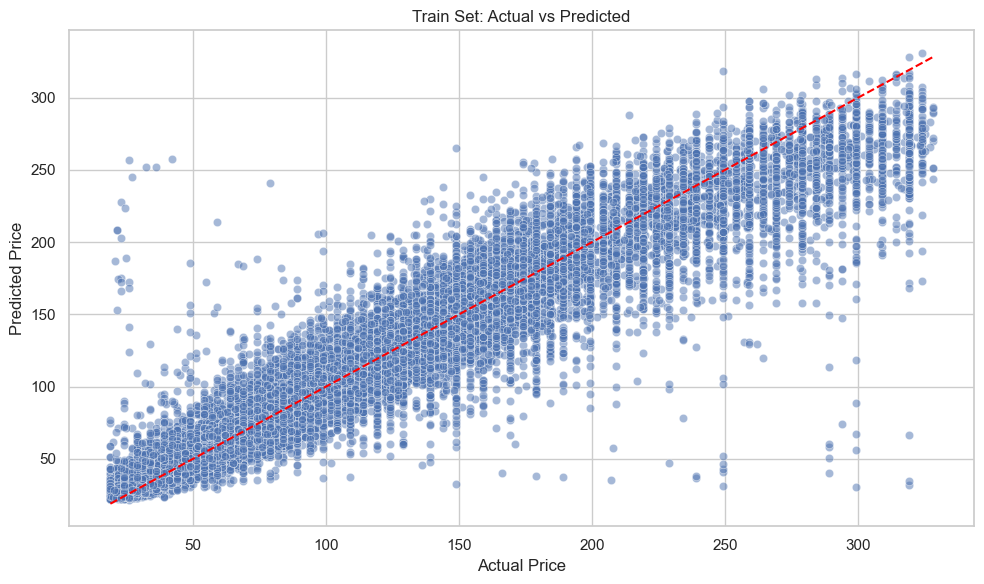

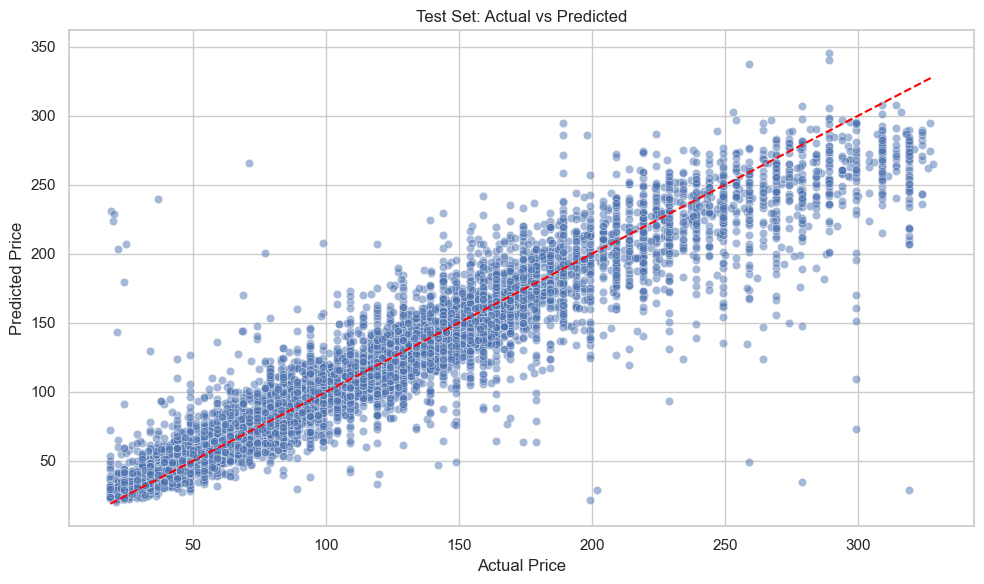

In [21]:
# --- Plot: Actual vs Predicted ---
def plot_actual_vs_pred(y_true, y_pred, title):
    plt.figure()
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.5)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], '--', color='red')
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_actual_vs_pred(y_train, y_train_pred, "Train Set: Actual vs Predicted")
plot_actual_vs_pred(y_test, y_test_pred, "Test Set: Actual vs Predicted")

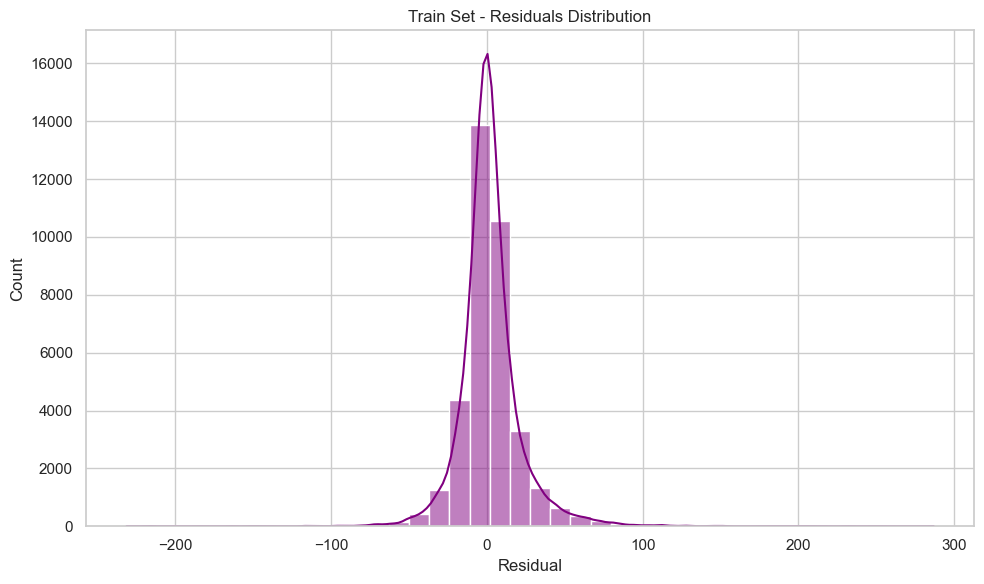

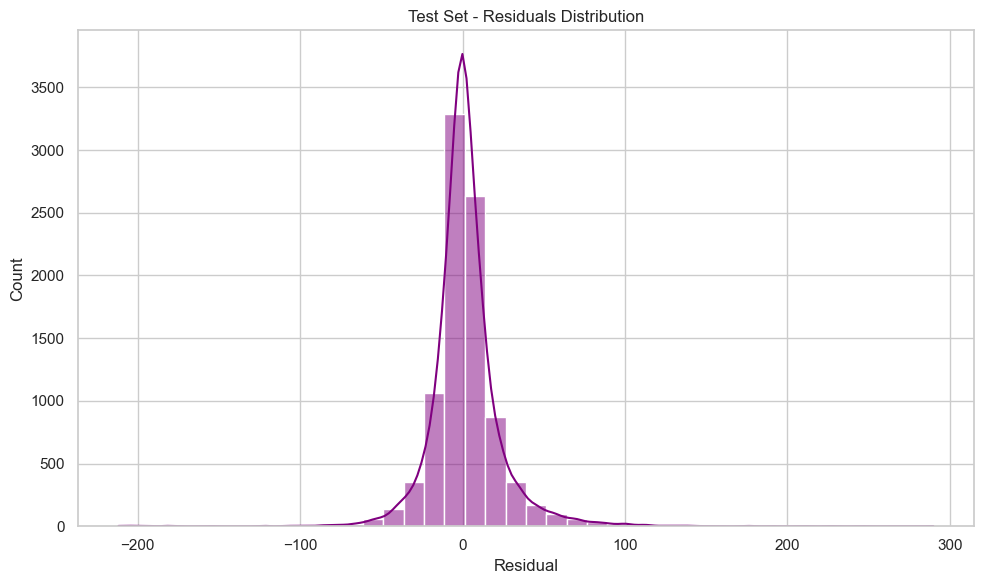

In [22]:
# --- Plot: Residuals ---
def plot_residuals(y_true, y_pred, title):
    residuals = y_true - y_pred
    plt.figure()
    sns.histplot(residuals, kde=True, bins=40, color='purple')
    plt.title(f"{title} - Residuals Distribution")
    plt.xlabel("Residual")
    plt.tight_layout()
    plt.show()

plot_residuals(y_train, y_train_pred, "Train Set")
plot_residuals(y_test, y_test_pred, "Test Set")

In [23]:
# Save the model
joblib.dump(model, 'Model/car_price_model.pkl')

# Save the target encoder
joblib.dump(target_encoder, 'Model/target_encoder.pkl')

# Save the scaler
joblib.dump(scaler, 'Model/standard_scaler.pkl')

FileNotFoundError: [Errno 2] No such file or directory: 'Model/car_price_model.pkl'